In [ ]:
import pandas as pd
import numpy as mp
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('Zomato-data.csv')
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet


## Data Cleaning

covert rate column to float by removing denominator char

In [ ]:
def handleRate(value):
    value = str(value).split('/')
    value = value[0]
    return value

df['rate'] = df['rate'].apply(handleRate)

In [ ]:
handleRate(value)

In [ ]:
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         148 non-null    object 
 1   online_order                 148 non-null    object 
 2   book_table                   148 non-null    object 
 3   rate                         148 non-null    float64
 4   votes                        148 non-null    int64  
 5   approx_cost(for two people)  148 non-null    int64  
 6   listed_in(type)              148 non-null    object 
dtypes: float64(1), int64(2), object(4)
memory usage: 8.2+ KB


In [22]:
df['rate'] = df['rate'].astype(float)

In [26]:
df.isna().sum()

name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
approx_cost(for two people)    0
listed_in(type)                0
dtype: int64

In [27]:
df

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet
...,...,...,...,...,...,...,...
143,Melting Melodies,No,No,3.3,0,100,Dining
144,New Indraprasta,No,No,3.3,0,150,Dining
145,Anna Kuteera,Yes,No,4.0,771,450,Dining
146,Darbar,No,No,3.0,98,800,Dining


### Exploring Restaurant Types

Text(0.5, 0, 'Type of restaurant types')

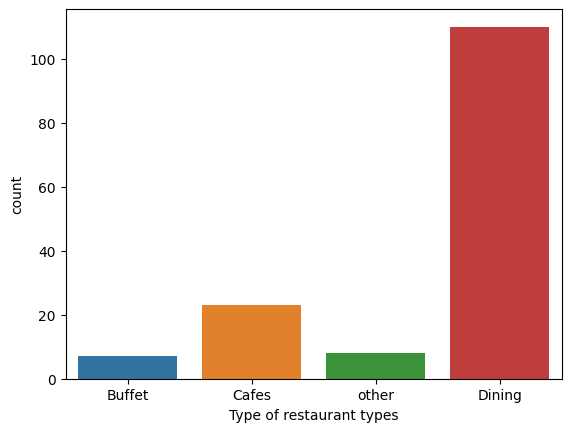

In [114]:
sns.countplot(x =df['listed_in(type)'],hue=df['listed_in(type)'])
plt.xlabel('Type of restaurant types')

The majority of restaurants fall into Dining Category

In [53]:
# votes for restaurant types
grouped_data =df.groupby('listed_in(type)')['votes'].sum()
result = pd.DataFrame({'votes' : grouped_data})

Text(0.5, 1.0, 'Votes for restaurants types')

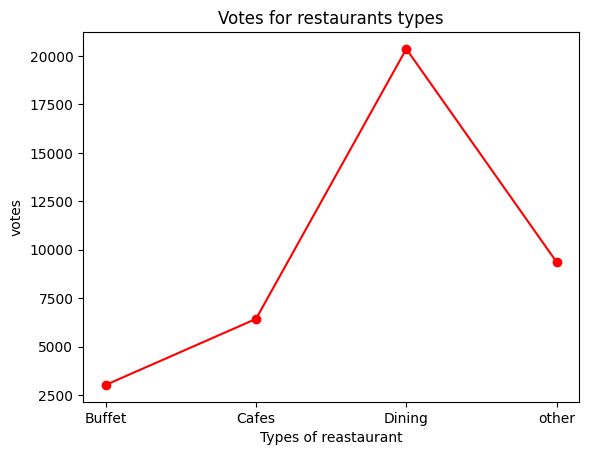

In [115]:
plt.plot(result, c='red' ,marker = 'o')
plt.xlabel('Types of reastaurant')
plt.ylabel('votes')
plt.title('Votes for restaurants types')

Dining restaurant are prefered by a larger number of individuals

In [65]:
# identify most voted restaurant
max_votes = df['votes'].max()
restaurant_with_max_votes = df.loc[df['votes'] == max_votes, 'name']
restaurant_with_max_votes

38    Empire Restaurant
Name: name, dtype: object

<Axes: xlabel='online_order', ylabel='count'>

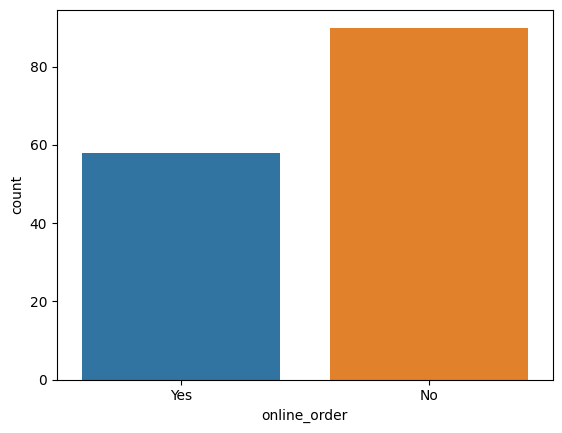

In [67]:
# online order availability
sns.countplot(x=df['online_order'],hue=df['online_order'])

This suggest that a majority of the restaurants do not accept online orders.

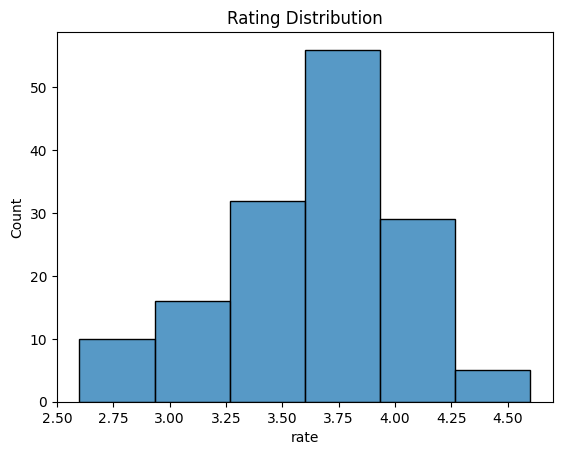

In [90]:
#Analyse ratings
sns.histplot(df['rate'],bins=6)
plt.title('Rating Distribution')
plt.show()

The majority of restaurants received rating ranging from 3.5 to 4

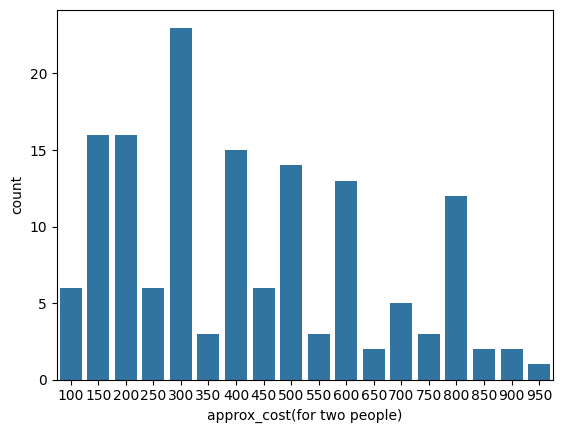

In [108]:
sns.countplot(x = df['approx_cost(for two people)'])
plt.show()

The majority of couples prefer restaurants with appox. cost of 300 rupees.

<Axes: xlabel='online_order', ylabel='rate'>

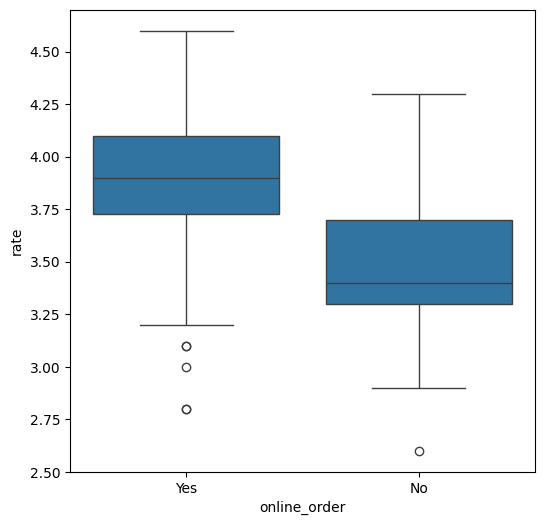

In [113]:
# rating comparision - online vs offline orders
plt.figure(figsize=(6,6))
sns.boxplot(x= 'online_order', y='rate',data=df)

Online rating recieve excellent rating which hase higher in comparison to offline order

In [125]:
df.groupby('listed_in(type)')['online_order'].size()

listed_in(type)
Buffet      7
Cafes      23
Dining    110
other       8
Name: online_order, dtype: int64

In [127]:
# Order mode preferences by Restaurant type
pivot_table = df.pivot_table(index='listed_in(type)', columns='online_order', aggfunc='size',fill_value=0)
pivot_table

online_order,No,Yes
listed_in(type),,
Buffet,3,4
Cafes,8,15
Dining,77,33
other,2,6


<Axes: xlabel='online_order', ylabel='listed_in(type)'>

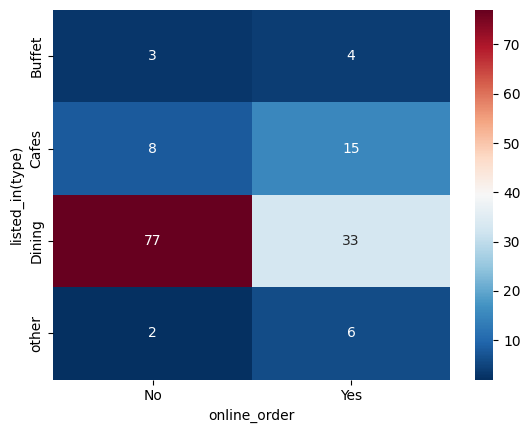

In [145]:
sns.heatmap(pivot_table, annot=True,cmap='RdBu_r')

with this we can say that dining restaurants accept offline orders whereas cafes primarily recieve online orders.
This suggest that clients prefer to place orders in person at restaurants but prefer online order in cafes.